# Plot OpenFAST Outputs

In [6]:
# Load all the tools
import numpy as np
# from wisdem.aeroelasticse.CaseLibrary import ROSCO_Test
import os, subprocess

# from openfast_io.FAST_reader import InputReader_Common, InputReader_OpenFAST, InputReader_FAST7
# from openfast_io.FAST_writer import InputWriter_Common, InputWriter_OpenFAST, InputWriter_FAST7
# from openfast_io.runFAST_pywrapper import runFAST_pywrapper_batch
# from openfast_io.CaseGen_General import CaseGen_General
# from openfast_io.CaseGen_IEC import CaseGen_IEC
# from pCrunch import pdTools
# from pCrunch import Processing, Analysis
# from openfast_io.Util import FileTools

# Instantiate fast_IO
from rosco.toolbox.ofTools.fast_io import output_processing

from rosco.toolbox.ofTools.util import spectral


import pandas as pd

import matplotlib.pyplot as plt
%matplotlib ipympl

i_fig = 0

Set outputs

In [40]:
outfiles = [
    # '/Users/dzalkind/Tools/ROSCO3/Examples/examples_out/12_ipc_sim/NREL2p8/ramp/base/NREL2p8_0.out',
    # '/Users/dzalkind/Tools/ROSCO3/Examples/examples_out/12_ipc_sim/NREL2p8/ramp/base/NREL2p8_1.out',
    # '/Users/dzalkind/Tools/ROSCO3/Examples/examples_out/12_ipc_sim/NREL2p8/ramp/base/NREL2p8_2.out',
    # '/Users/dzalkind/Tools/ROSCO3/Examples/examples_out/12_ipc_sim/NREL2p8/ramp/base/NREL2p8_3.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/12_ipc_sim/NREL2p8_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/0_baseline/RM1_MHK_0.outb',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/1_const_torque/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/2_startup/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/3_sweep_fl_gain/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/3_sweep_fl_gain/RM1_MHK_2.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/3_sweep_fl_gain/RM1_MHK_4.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/4_sweep_omega_pc/RM1_MHK_0.outb',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/4_sweep_omega_pc/RM1_MHK_1.outb',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/4_sweep_omega_pc/RM1_MHK_2.outb',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/4_sweep_omega_pc/RM1_MHK_3.outb',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/5_remove_filters/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/6_sweep_kp/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/6_sweep_kp/RM1_MHK_2.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/6_sweep_kp/RM1_MHK_4.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/7_try_high_kp_low_om/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/8_sweep_freq/RM1_MHK_0.out', # This was a good one
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/8_sweep_freq/RM1_MHK_1.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/8_sweep_freq/RM1_MHK_2.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/9_no_gen/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/10_no_ptfm/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/11_update_hydro/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/12_update_moor/RM1_MHK_0.outb',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/14_no_gen/RM1_MHK_0.outb',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/15_new_model_ic/RM1_MHK_0.outb',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/16_check_cycle/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/17_cook_setup/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/18_no_cavit/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/19_long_run/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/20_subset_no_waves/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/21_slow_control/RM1_MHK_0.out',
    '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/22_peak_shaving/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/24_speed_up/RM1_MHK_0.out',
    '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/25_fast_const_pwr/RM1_MHK_0.out',
    # '/Users/dzalkind/Tools/ROSCO-main/Examples/examples_out/26_MHK/23_const_torque/RM1_MHK_0.out',

]

# outfiles

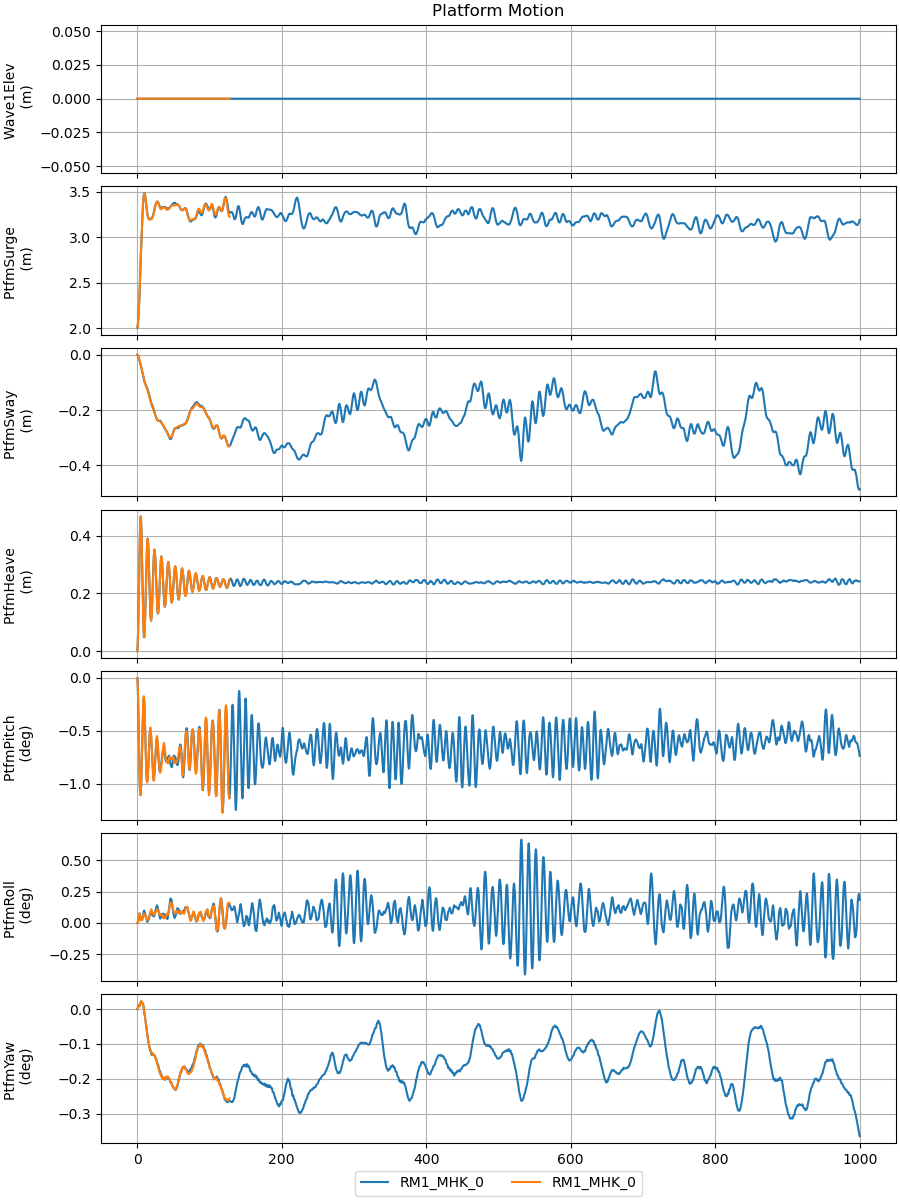

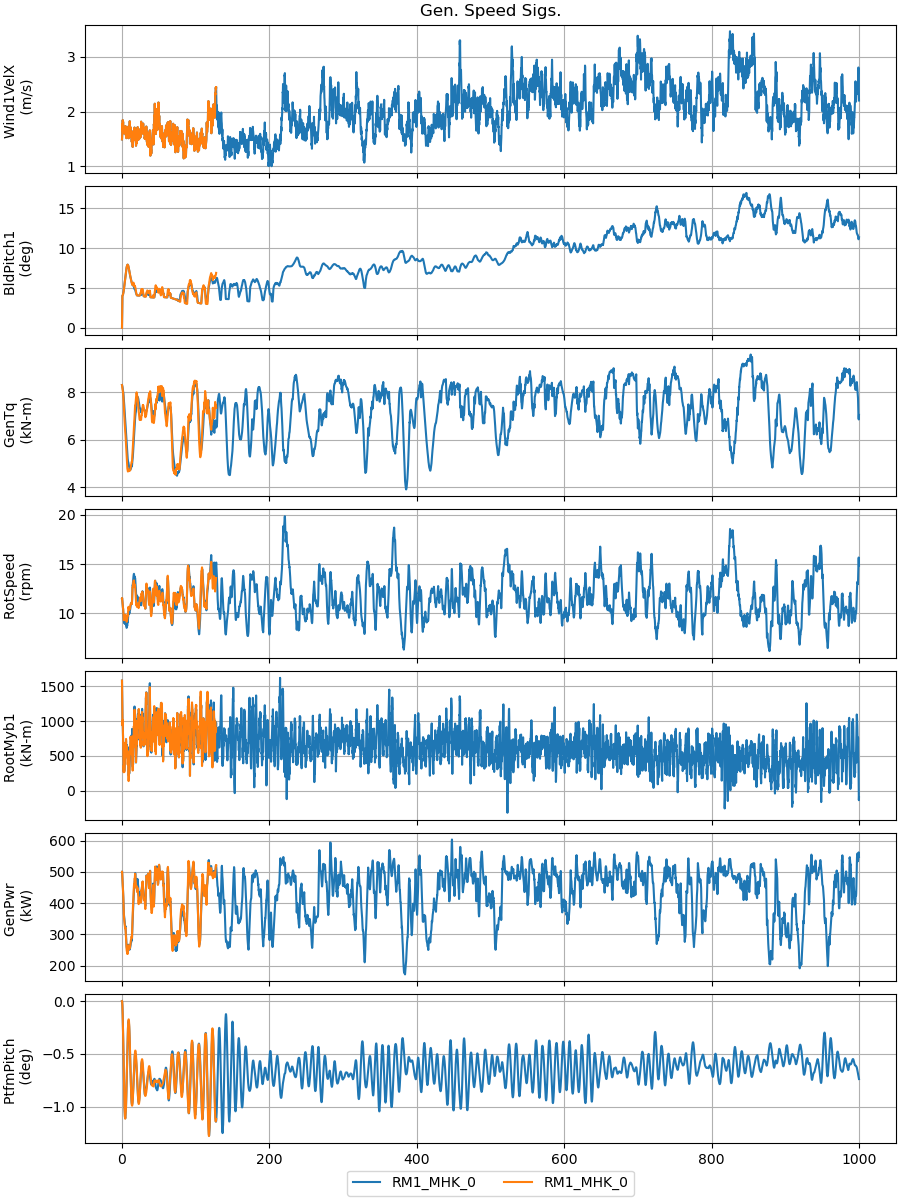

In [41]:
output_ext = '.out'
plt.rcParams["figure.figsize"] = [9,12]

ROSCO = False
ROSCO2 = False

#  Define Plot cases 
cases = {}
# cases['Gen. Speed Sigs.'] = ['Wind1VelX', 'BldPitch1', 'GenTq', 'GenSpeed','TwrBsMyt','GenPwr','RootMyb1']#,'PtfmPitch','PtfmYaw','NacYaw']
cases['Gen. Speed Sigs.'] = ['Wind1VelX','BldPitch1', 'GenTq', 'RotSpeed','RootMyb1','GenPwr','PtfmPitch']#,'','PtfmYaw','NacYaw']
# # cases['Debug'] = ['IPDefl1','OoPDefl1','Azimuth','RotTorq']#,'PtfmPitch','PtfmYaw','NacYaw']
# cases['Plt. Control Sigs.'] = ['Fl_PitCom', 'PC_MinPit']
cases['Platform Motion'] = ['Wave1Elev','PtfmSurge', 'PtfmSway', 'PtfmHeave', 'PtfmPitch','PtfmRoll','PtfmYaw']
# # cases['Tower Loads'] = ['TwrBsFxt','TwrBsFyt', 'TwrBsFzt', 'TwrBsMxt', 'TwrBsMyt','TwrBsMzt']
# # cases['Rot Thrust'] = ['RtVAvgxh','BldPitch1','RotThrust']
# cases['IPC'] = [('PC_PitComT','BlPitchCMeas'),'PitComAct']
# cases['SPS'] = ['SS_DelOmega','PC_RefSpd','VS_RefSpd','GenSpeed']
# # cases['IPC'] = ['PtfmYaw','YawBrMzp','YawBrMyp']

# cases['Gen. Speed Sigs.'] = ['Wind1VelX', 'GenPwr', 'RotSpeed', 'GenSpeed', 'GenTq', 'BldPitch1','B1RootMyr'] #, 'PtfmPitch','PtfmYaw'] #,'PtfmPitch','PtfmYaw','NacYaw']
# cases['Rot. Pos'] = ['RotSpeed',('BldPitch1','BldPitch2','BldPitch3'),'GenTq','Azimuth']
# cases['Rotor Position'] = ['AzError','GenTqAz','Azimuth','AzUnwrapped','OL_Azimuth']
# cases['Aero'] = ["B1N3Alpha","B1N3Cd","B1N3Cl"]


op = output_processing.output_processing()
op_RO = output_processing.output_processing()
op_RO2 = output_processing.output_processing()



fast_out = []
fast_out = op.load_fast_out(outfiles, tmin=0)
if ROSCO:
    # Rosco outfiles
    r_outfiles = [out.split('.out')[0] + '.RO.dbg' for out in outfiles]
    rosco_out = op_RO.load_fast_out(r_outfiles, tmin=0)
    
    if ROSCO2:
        r_outfiles = [out.split('.out')[0] + '.RO.dbg2' for out in outfiles]
        rosco_out2 = op_RO2.load_fast_out(r_outfiles, tmin=0)
  
# Combine outputs
if ROSCO:
    comb_out = [None] * len(fast_out)
    for i, (r_out, f_out) in enumerate(zip(rosco_out,fast_out)):
        r_out.update(f_out)
        comb_out[i] = r_out
    if ROSCO2:
        for i, (r_out2, f_out) in enumerate(zip(rosco_out2,comb_out)):
            r_out2.update(f_out)
            comb_out[i] = r_out2
else:
    comb_out = fast_out

# comb_out
# if False:
#     comb_out[0]['meta']['name'] = 'Variable Bandwidth'

    
# Plot
fig, ax = op.plot_fast_out(comb_out,cases, showplot=True)

if False:  # Print!
    
    save_fig_dir = '/Users/dzalkind/Projects/CarbonTrust/Deliverables'
    for f in fig:
        f.savefig(os.path.join(save_fig_dir,'ts'+str(i_fig)))
        i_fig += 1

output_ext = '.out'
plt.rcParams["figure.figsize"] = [9,7]



In [9]:
# Create hub height wind speed for RM1 that's half a cycle

period = 43200 * 2

t = np.arange(0,period/2,0.1)
max_speed = 4

uu = max_speed * (np.sin(2*np.pi*t/period))

plt.plot(t, uu)

from rosco.toolbox.ofTools.case_gen import HH_WindFile

hh_wind = HH_WindFile.HH_WindFile(**{
    'TMax': period / 2,
    'dt': t[1]-t[0]
})
hh_wind.wind_speed = uu
hh_wind.time = t
hh_wind.resample()

hh_wind.filename = f'/Users/dzalkind/Tools/ROSCO-main/Examples/26_MHK/RM1_HH_WindFile_p{period}_u{max_speed}.txt'

hh_wind.write()






In [ ]:
# Read the Cook Inlet file
cook_inlet_file = '/Users/dzalkind/Tools/ROSCO-main/Examples/26_MHK/Cook_Inlet.txt'

# Read the data
# cook_data = pd.read_csv(cook_inlet_file, delim_whitespace=True, skip_rows=12,
# names=['Time', 'Wind_Speed','Wind_dir','Vert_speed','Horiz_shear','P_vert_shear','L_vert_shear','Gust_speed','Upflow'])

# # Display basic info about the data
# print(f"Cook Inlet data shape: {cook_data.shape}")
# print(f"Time range: {cook_data['Time'].min():.1f} to {cook_data['Time'].max():.1f} seconds")
# print(f"Wind speed range: {cook_data['Wind_Speed'].min():.3f} to {cook_data['Wind_Speed'].max():.3f} m/s")

# # Plot the Cook Inlet data
# plt.figure(figsize=(12, 6))
# plt.plot(cook_data['Time'], cook_data['Wind_Speed'])
# plt.xlabel('Time (s)')
# plt.ylabel('Wind Speed (m/s)')
# plt.title('Cook Inlet Wind Speed Time Series')
# plt.grid(True)
# plt.show()

# ! Time     Wind    Wind    Vertical    Horiz.      Pwr.Law     Lin.Vert.   Gust     Upflow 
# !          Speed   Dir     Speed       Shear       Vert.Shr    Shear       Speed    Angle  

# cook_data.columns = ['Time', 'Wind_Speed','Wind_dir','Vert_speed','Horiz_shear','P_vert_shear','L_vert_shear','Gust_speed','Upflow']
# cook_data.head()
# 1+1

cook_data



In [20]:
cook_inlet_file = '/Users/dzalkind/Tools/ROSCO-main/Examples/26_MHK/Cook_Inlet.txt'

header_lines = 13
time_subset = [6000, 7000]  # seconds

cook_data = pd.read_csv(cook_inlet_file, delim_whitespace=True, skiprows=header_lines,
names=['Time', 'Wind_Speed','Wind_dir','Vert_speed','Horiz_shear','P_vert_shear','L_vert_shear','Gust_speed','Upflow'])

cook_data

inds = np.bitwise_and(cook_data['Time'] >= time_subset[0], cook_data['Time'] <= time_subset[1])

new_cd = cook_data.loc[inds]
new_cd['Time'] = new_cd['Time'] - time_subset[0]

new_cd

# Write the new data back to a file with the same header
output_file = '/Users/dzalkind/Tools/ROSCO-main/Examples/26_MHK/Cook_Inlet_subset.txt'

# Read the original header (first header_lines lines)
with open(cook_inlet_file, 'r') as f:
    header_lines = [f.readline() for _ in range(header_lines)]

# Write the new file with original header and subset data
with open(output_file, 'w') as f:
    # Write header
    for line in header_lines:
        f.write(line)
    
    # Write the subset data
    new_cd.to_csv(f, sep='\t', index=False, header=False, float_format='%12.6f')

print(f"Subset data written to: {output_file}")



Subset data written to: /Users/dzalkind/Tools/ROSCO-main/Examples/26_MHK/Cook_Inlet_subset.txt


/var/folders/hy/62hqjp8d0msbfgf6r6jvj5cw3rr_2y/T/ipykernel_63012/852128302.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cook_data = pd.read_csv(cook_inlet_file, delim_whitespace=True, skiprows=header_lines,
/var/folders/hy/62hqjp8d0msbfgf6r6jvj5cw3rr_2y/T/ipykernel_63012/852128302.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_cd['Time'] = new_cd['Time'] - time_subset[0]


In [ ]:
2 * np.pi / 10

In [ ]:
60 / 12

In [ ]:

ind = comb_out[0]['Time'] > 120
a = np.array([co['RootMyb1'][ind].std() for co in comb_out])
b = np.array([co['BldPitch1'][ind].std() for co in comb_out])

fig, axs = plt.subplots(2,1)
axs[0].plot(a)
axs[1].plot(b)



In [ ]:
18*20


In [ ]:
# plot thrust spectra

df = pd.DataFrame()

for i in range(3):
    fq, y, _ = spectral.fft_wrap(
                        fast_out[i]['Time'], fast_out[i]['RotThrust'], averaging='Welch', averaging_window='Hamming', output_type='psd')

    plt.plot(fq,np.sqrt(y))
    
    df['fq_'+str(i)] = fq
    df['psd_'+str(i)] = y
    
#     fq, y, _ = spectral.fft_wrap(
#                         fast_out[i]['Time'], fast_out[i]['RtVAvgxh'], averaging='Welch', averaging_window='Hamming', output_type='psd')

#     plt.plot(fq,np.sqrt(y))
    
#     fq, y, _ = spectral.fft_wrap(
#                     fast_out[i]['Time'], fast_out[i]['Wind1VelX'], averaging='Welch', averaging_window='Hamming', output_type='psd')

#     plt.plot(fq,np.sqrt(y))
    
    
    
    
    
plt.yscale('log')
plt.xscale('log')

plt.xlim([1e-2,10])
plt.grid('True')

plt.xlabel('Freq. (Hz)')
plt.ylabel('PSD')


df.to_pickle('/Users/dzalkind/Tools/RAFT/designs/rotors/thrust_psd.p')
df

In [ ]:
# Plot Spectral

_,_,max_periods = op.plot_spectral(fast_out,[('PtfmYaw',0),('PtfmYaw',1)],showplot=False,detrend=True)
yaw_fast = fast_out[0]['PtfmYaw']
std_yaw_fast = np.std(yaw_fast)
amp = std_yaw_fast * np.sqrt(2)




# save_yaml(dir_matrix, 'case_matrix.yaml', matrix_out_yaml)

# op

In [29]:
np.degrees(0.0543)

np.float64(3.1111608275603704)